# eBay Laptops & Notebooks - Data Cleansing

The following dataset contains information about laptops and notebooks, by web scraping the popular e-commerce website
**eBay**.

The dataset contains information about the laptop prices (possible variable of interest), brand, ratings, condition, as well as hardware information (processor, screen size, ram, etc).

<div style="text-align: center;">
<img src="../assets/logos/ebay.png" width="250"/>
</div>

## Loading Libraries

We are using **Polars** for data cleansing. Polars is a **fast**, ***parallel**, and **memory-efficient** DataFrame library written in *Rust*, designed for handling large datasets.

It provides intuitive API operations for data manipulation, such as filtering, grouping, joining, and transforming data, all in a very efficient manner. Unlike other popular libraries like Pandas, Polars is optimized for performance and can handle larger datasets with significantly faster execution times.
During the data cleaning process, we will leverage Polars to:
- Load and transform the data
- Clean and map columns based on custom logic
- Perform various aggregations and groupings
- Handle null values and ensure consistency across the dataset

Polars supports both eager and lazy execution modes, making it flexible for a variety of use cases.

<div style="text-align: center;">
<img src="../assets/logos/polars.png"/>
</div>

In [176]:
# Importing libraries and setting constants

import re
from typing import Optional, Tuple

import polars as pl
from polars import LazyFrame

# Data source location
DATA_SOURCE_PATH = '../data/ebay_laptops_and_notebooks.csv'

## Data Exploration

In [177]:
# Loading the dataset
df = pl.read_csv(DATA_SOURCE_PATH)

# Top 10 rows from the dataframe
df.head(n=10)

Brand,Price,Rating,Ratings Count,Condition,Seller Note,Processor,Screen Size,Manufacturer Color,Color,Ram Size,SSD Capacity,GPU,Processor Speed,Type,Release Year,Maximum Resolution,Model,OS,Features,Hard Drive Capacity,Country Region Of Manufacturer,Storage Type
str,str,str,i64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""CHUWI""","""$303.68 """,null,null,"""New: A brand-new, unused, unop…",null,"""Quad Core""","""14 in""",null,"""Gray""","""8 GB""","""1 Used, 1 support Max 1TB M.2…","""Intel Iris Plus Graphics 655""","""Max up to 3.80 GHz""","""Notebook/Laptop""","""2021""","""2160 x 1440""","""CoreBook X""","""Windows 11 Home""","""Backlit Keyboard, Built-in Mi…","""512 GB SSD""","""China""","""SSD (Solid State Drive)"""
"""Dell""","""$399.99 to $634.99""",null,null,"""Very Good - RefurbishedThe ite…","""“AAA PCs is a Microsoft Author…","""Intel Core i7 8th Gen.""","""14 in""",null,"""Black""",null,null,"""Intel UHD Graphics 620""","""4.20 GHz (1.90 GHz Base Freque…","""Notebook/Laptop""","""Refurbished in 2023""","""1920 x 1080""","""Dell Latitude 7490""","""Windows 11 Pro""","""Backlit Keyboard, Bluetooth, B…","""2 TB""",null,"""SSD (Solid State Drive)"""
"""Dell""","""$175.00 """,null,null,"""UsedAn item that has been used…","""“Well kept, fully functional, …","""Intel Core i5-6300U""","""14 in""",null,"""Black""","""16 GB""","""500 GB""","""Intel HD Graphics""","""2.40 GHz""","""Notebook/Laptop""","""2019""","""1920 x 1080""","""Dell Latitude E5470""","""Windows 10 Pro""","""10/100 LAN Card, Backlit Keybo…","""500 GB""","""China""","""SSD (Solid State Drive)"""
"""HP""","""$84.99 """,null,null,"""Good - RefurbishedThe item sho…","""“1-Year Allstate warranty. The…","""Intel Celeron N""","""11.6 in""",null,"""Black""","""4 GB""",null,"""Intel HD Graphics 500""","""2.40 GHz""","""Notebook/Laptop""",null,"""1366 x 768""","""HP Chromebook 11 G6""","""Chrome OS""","""Bluetooth, Built-in Microphone…","""16 GB""",null,"""eMMC"""
"""Dell""","""$101.22 """,null,null,"""Good - RefurbishedThe item sho…","""“Laptops is tested & fully wor…","""Intel Core i5 6th Gen.""","""Minimum 12.5""""",null,null,"""8 GB""","""256 GB""","""Integrated""","""Minimum 1.40 GHz""","""Notebook/Laptop""","""2015""","""1366 x 768""","""Various Models""","""Windows 10""","""10/100 LAN Card, Built-in Micr…","""NO HDD""",null,"""SSD (Solid State Drive)"""
"""Acer""","""$49.99 ""","""4.5 out of 5 stars""",193,null,null,"""Intel Celeron""","""11.6 in""","""Black""","""Black""","""4 GB""","""16 GB""",null,"""1.60 GHz""","""Laptop""","""2017""","""1366 x 768""","""Chromebook C738T-C44Z""","""Chrome OS""","""Touchscreen, Bluetooth""",null,null,"""SSD (Solid State Drive)"""
"""HP""","""$39.59 ""","""4.5 out of 5 stars""",23,null,null,"""Intel Celeron""","""11.6 in""",null,"""Black""","""4 GB""","""16GB""",null,"""1.60 GHz""","""Notebook/Laptop""","""2017""",null,"""HP Chromebook 11 G5""","""Chrome OS""","""Bluetooth, Built-in Webcam""","""16 GB""",null,"""SSD (Solid State Drive)"""
"""Acer""","""$34.99 ""","""5 out of 5 stars""",20,null,null,"""Intel Celeron Dual-Core""","""11.6 inin""",null,"""Gray, Granite Gray""","""2GB""",null,null,"""1.00 GHz.4ghz""","""Netbook""",null,null,"""Chromebook C720-2848""","""Chrome OS""",null,"""16GB""",null,null
"""Dell""","""$279.99 """,null,null,"""Excellent - Refurbished: The i…",null,"""i7 7th""","""14 in""",null,"""Black""","""16 GB""","""500 GB""",null,"""2.80 GHz""","""Notebook/Laptop""",null,"""1920 x 1080""","""Dell Latitude 7480""","""win 11 pro""","""Wi-Fi""","""512 GB""",null,"""SSD (Solid State Drive)"""


Observations:

* `Price` variable contains information about the price itself, but also the currency. Also, some prices are in a range format, such as `$399.99 to $634.99` which needs to be handled before converting `Price` into a numerical variable.
* **Several** columns are being treated as `String` (such as `Price`), which might not be adequate.
* **Several** columns have **missing values**, which needs to be treated during further data preprocessing.

### Summary Statistics

We compute the summary statistics for our dataset, but we instantly notice most of our columns are nullable, which makes statistics, such as the mean and standard deviation, to output `null` too.

In [178]:
# Summary statistics
df.describe()

statistic,Brand,Price,Rating,Ratings Count,Condition,Seller Note,Processor,Screen Size,Manufacturer Color,Color,Ram Size,SSD Capacity,GPU,Processor Speed,Type,Release Year,Maximum Resolution,Model,OS,Features,Hard Drive Capacity,Country Region Of Manufacturer,Storage Type
str,str,str,str,f64,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""count""","""4024""","""6620""","""286""",286.0,"""6004""","""1442""","""3837""","""3890""","""185""","""2149""","""2112""","""2780""","""3088""","""2669""","""3289""","""787""","""2480""","""3148""","""3040""","""2505""","""2332""","""203""","""2388"""
"""null_count""","""2596""","""0""","""6334""",6334.0,"""616""","""5178""","""2783""","""2730""","""6435""","""4471""","""4508""","""3840""","""3532""","""3951""","""3331""","""5833""","""4140""","""3472""","""3580""","""4115""","""4288""","""6417""","""4232"""
"""mean""",null,null,null,42.479021,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""std""",null,null,null,201.257428,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""min""","""?""","""$1,002.67 ""","""1 out of 5 stars""",1.0,"""Certified - Refurbished: The i…","""“""Excellent Condition Touch Sc…","""10th Gen Intel Core i5""","""10 in""","""3000""","""Abyss Blue""","""1 GB""",""".""",""".""","""1.00 GHz""","""2 IN 1 CHROMEBOOK""","""0""","""1024 x 480""","""100e Chromebook""","""ANDROID""",""".""",""".""","""Australia""","""."""
"""25%""",null,null,null,2.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""50%""",null,null,null,4.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""75%""",null,null,null,20.0,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null
"""max""","""xnote""","""$999.95 ""","""5 out of 5 stars""",1533.0,"""Very Good - RefurbishedThe ite…","""“✅ Refurbished ✅ inkl. 19% MwS…","""unknown""","""none""","""onyx black""","""see pictures""","""up to 32GBGB DDR4""","""up to 1TB SSD""","""‎PowerVR GX6250""","""up to 3.6Ghz""","""Écran numériseur""","""see manufacturer""","""See Title/Description""","""xnote""","""‎Windows 11 Home""","""dvd""","""up to 1 TB""","""Unknown""","""ssd"""


### Null Count and Null Proportion

Now, we take a look at the `null count` and `null proportion` per each dataframe column:

In [179]:
# Nulls per each column in the dataset
df.null_count().unpivot(
    variable_name='variable',
    value_name='null_count',
).sort(
    by='null_count', descending=True,
).with_columns(
    (pl.col('null_count') / df.height).round(2).alias('null_proportion'),
)

variable,null_count,null_proportion
str,u32,f64
"""Manufacturer Color""",6435,0.97
"""Country Region Of Manufacturer""",6417,0.97
"""Rating""",6334,0.96
"""Ratings Count""",6334,0.96
"""Release Year""",5833,0.88
…,…,…
"""Processor""",2783,0.42
"""Screen Size""",2730,0.41
"""Brand""",2596,0.39


Observations:

- Extremely high percentage (85%+) of nulls for columns such as `country_region_of_manufacturer`, `ratings_count` or `release_year`.
- `Price` column has no null values.

### Data Types

We look at each column data type in the data frame

In [180]:
# Data Types
pl.DataFrame(data={
    'column': df.columns,
    'dtype': df.dtypes
})

column,dtype
str,object
"""Brand""",String
"""Price""",String
"""Rating""",String
"""Ratings Count""",Int64
"""Condition""",String
…,…
"""OS""",String
"""Features""",String
"""Hard Drive Capacity""",String


As aforementioned, some variables which are currently being treated as `String`, such as `Price`, are actually numerical. It's very important to find out whether this is a single column, or there are more occurrences within the dataframe.

## Data Preparation

## Column Renaming

We kick things off by *reformatting* the column names: lowercasing and removing spaces for underscores. These convention for string data will be **STANDARD** during our data cleansing process, so that most categorical data is transformed into similar formatting.

In [181]:
# Renaming columns: replacing blank spaces for underscores and lowercasing columns
df = df.rename({col: col.strip().lower().replace(' ', '_') for col in df.columns})
print(df.columns)

['brand', 'price', 'rating', 'ratings_count', 'condition', 'seller_note', 'processor', 'screen_size', 'manufacturer_color', 'color', 'ram_size', 'ssd_capacity', 'gpu', 'processor_speed', 'type', 'release_year', 'maximum_resolution', 'model', 'os', 'features', 'hard_drive_capacity', 'country_region_of_manufacturer', 'storage_type']


## Utility Functions

In [182]:
def value_counts_with_proportion(dataframe: pl.DataFrame,
                                 col: str,
                                 proportion_col_alias: str = 'proportion',
                                 to_pandas: bool = False) -> pl.DataFrame:
    """
    Calculate the value counts for a specified column in a Polars DataFrame and return a DataFrame with
    the counts and their corresponding proportions.

    Args:
        col (str): The name of the column for which value counts should be calculated.
        dataframe (pl.DataFrame, optional): The Polars DataFrame on which the operation should be performed.
                                            Defaults to the global 'df' variable.
        proportion_col_alias (str, optional): The alias name for the proportion column. Defaults to 'proportion'.
        to_pandas (bool, optional): Whether to convert the result to a Pandas DataFrame. Defaults to False.

    Returns:
        pl.DataFrame or pd.DataFrame: A DataFrame containing the unique values in the specified column, their respective
                                      counts, and their proportions (as a percentage of the total number of rows).
                                      The result is a Polars DataFrame by default, but can be returned as a Pandas DataFrame
                                      if `to_pandas=True`.

    Example:
        # Sample DataFrame
        df = pl.DataFrame({
            "category": ["A", "B", "A", "C", "B", "B", "C", "A", "A"]
        })

        # Usage of the function
        result = value_counts_with_proportion(col="category", dataframe=df)
        print(result)

    Output:
        shape: (3, 3)
        ┌─────────┬────────┬────────────┐
        │ category│ count  │ proportion │
        │ ---     │ ---    │ ---        │
        │ str     │ i64    │ f64        │
        ├─────────┼────────┼────────────┤
        │ A       │ 4      │ 0.44       │
        │ B       │ 3      │ 0.33       │
        │ C       │ 2      │ 0.22       │
        └─────────┴────────┴────────────┘

    Notes:
        - The function uses `value_counts()` to compute the frequency of each unique value in the specified column.
        - The proportions are calculated by dividing the count of each unique value by the total number of rows (`df.height`).
        - The proportions are rounded to 2 decimal places.
        - The function supports parallel processing for faster execution on large datasets.
    """
    # Compute value counts with proportions
    sorted_df_with_prop = dataframe[col].value_counts(
        sort=True,
        parallel=True,
    ).with_columns(
        (pl.col('count') / dataframe.height).round(2).alias(proportion_col_alias)
    )

    # Return as Pandas DataFrame if to_pandas=True, else return Polars DataFrame
    return sorted_df_with_prop.to_pandas() if to_pandas else sorted_df_with_prop


## Cleaning `brand`
- **Top categories**: The top three brands—Dell (19%), Lenovo (11%), and HP (7%)—represent a combined 37% of the total brands in the dataset. The null values account for 39% of the data, with 2596 entries marked as null. This is quite a large portion of the dataset. The top 4 categories (`null`, `Dell`, `Lenovo` & `HP`) account for 76% of the dataset.
- **Unknown values**: There's an abundance of brands with very low frequencies, or unknown values (like `?` or `Does not apply`).
- **Inconsistent formatting**: Some entries like `Dell Inc` are not captured under the main brand `Dell` due to inconsistent formatting. Similar things occur to other top brands.
- **Multibrand categories**: Some entries represent several brands, like `Dell / HP / Lenovo` or `Apple / LG`

In [183]:
# Taking a look at the frequency of each brand: total count and proportion
value_counts_with_proportion(dataframe=df, col='brand')

brand,count,proportion
str,u32,f64
null,2596,0.39
"""Dell""",1273,0.19
"""Lenovo""",715,0.11
"""HP""",494,0.07
"""Acer""",147,0.02
…,…,…
"""Frontier""",1,0.0
"""Dell/HP/Lenovo/Stone""",1,0.0
"""SCSI""",1,0.0


### **Reformatting `brand`:**

In this step of our analysis, we're focusing on cleaning up and standardizing the `brand` data to ensure consistency and accuracy. Brands can be listed in many different ways, which can lead to confusion or misinterpretation during analysis. So, we're transforming the brand names into a uniform format that makes it easier to work with.

- **Consistent Formatting:** We ensure all brand names are in lowercase, and we remove any unnecessary spaces or punctuation that could create inconsistencies. (transforming `Dell Inc` into `dell_inc`).
- **Replacing Uncertain Values:** We also handle special cases where the data might have uncertain or irrelevant values (e.g., a "?" for unknown brands), replacing them with more meaningful terms like "unbranded" or "unknown."


In [184]:
# Define a mapping to replace certain placeholder values with more meaningful labels.
brand_replace_map = {
    '?': 'unbranded',  # Replace '?' with 'unbranded' for unknown brands.
    'does_not_apply': 'not_applicable',  # Replace 'does_not_apply' with 'not_applicable' to handle irrelevant data.
}

# Clean and normalize the brand names.
df = df.with_columns(
    pl.col('brand')
    .str.to_lowercase()  # Convert brand names to lowercase to ensure uniformity.
    .str.strip_chars()  # Remove any leading whitespace or special characters.
    .str.strip_chars_end('.')  # Specifically remove any trailing dots at the end of brand names.
    .str.replace_all(' / |\\/', ' or ')  # Replace slashes ("/" or " / ") with ' or ' to standardize multi-brand names.
    .str.replace_all(' ', '_')  # Replace spaces with underscores to ensure no spaces in brand names.
    .replace(brand_replace_map)  # Replace values like '?' or 'does_not_apply' based on the predefined map.
    .fill_null('unknown')  # Fill any missing brand values with 'unknown' to handle missing data.
    .alias('brand_clean')
)

### **Identifying and Mapping Top Brands:**

In this step, we're focusing on identifying the most popular brands in the dataset and ensuring that any variations in the brand names are mapped to the correct top brand.

- **Identifying Top Brands:** We start by filtering out any unknown brand names and then count the occurrences of each brand. From this, we identify the top 5 brands with the highest frequency in the dataset.
- **Pattern Matching:** We create a pattern to search for these top brands in the brand names. If the brand name matches one of the top brands (e.g., includes "dell", "hp", etc.), we recognize it as a valid entry for that brand.
- **Mapping Variations to Top Brands:** We then apply a function to map variations of the brand names (e.g., "dell_epsilon" or "hp_dell") to the main brand names (e.g., "dell" or "hp"). This ensures that similar or ambiguous entries are standardized to the correct top brand.

By applying these steps, we ensure that any variations or inconsistencies in the brand names are correctly mapped to the top brands, improving the consistency and accuracy of our analysis.


In [185]:
# Identify the top 5 most frequent brands in the dataset.
top_brands = (
    df.filter(pl.col('brand_clean').ne('unknown'))
    .group_by('brand_clean')
    .agg(pl.len().alias('count'))
    .sort('count', descending=True)
    .head(5)
    .select('brand_clean')
    .to_series()
)

# Create a regex pattern to match brand names followed by an underscore (_).
is_a_top_brand_string_pattern = "|".join(re.escape(color) for color in top_brands + '_')


# Function to extract the actual brand from a string.
def fetch_first_matching_brand_from_str(string: str, brand_list: list[str] = top_brands) -> str:
    """
    Extracts the first matching brand from a given string.

    Args:
        string (str): The input string containing the brand.
        brand_list (list): List of top brands to check against.

    Returns:
        str: The first matched brand if found; otherwise, the original string.
    """
    for brand in brand_list:
        if brand + '_' in string:
            return brand
    return string


# Apply the brand extraction function to standardize brand names.
df = df.with_columns(
    pl
    # Check if the brand contains any of the top brands and isn't a mixed brand like "dell_or_hp".
    .when(
        pl.col('brand_clean').str.contains(is_a_top_brand_string_pattern) &
        ~pl.col('brand_clean').str.contains('_or_')
    )
    # If the condition is met, map the brand name to its standardized version.
    .then(pl.col('brand_clean').map_elements(fetch_first_matching_brand_from_str, return_dtype=pl.Utf8))
    # Otherwise, keep the original brand name.
    .otherwise(pl.col('brand_clean'))
    # Rename the transformed column as 'brand_clean'.
    .alias('brand_clean')
)


In [186]:
# Taking another look at the frequency of each brand: total count and proportion
value_counts_with_proportion(dataframe=df, col='brand_clean')

brand_clean,count,proportion
str,u32,f64
"""unknown""",2596,0.39
"""dell""",1300,0.2
"""lenovo""",720,0.11
"""hp""",494,0.07
"""acer""",150,0.02
…,…,…
"""frontier""",1,0.0
"""dell_or_hp_or_lenovo_or_stone""",1,0.0
"""scsi""",1,0.0


Observations:
- **More records assigned to `dell`**: `dell` has more than 20 new records. (from `1273` to `1300`). Likely due to previously fragmented brand variations (e.g., `dell_inc`, `dell_xps`) now being mapped correctly to `dell`.
- **Consistent top brands**: The overall ranking of top brands did not change. The counts for `acer` (150), `lg` (125), `fujitsu_siemens` (123), `samsung` (122), `microsoft` (119), and AUO (114) remained stable, indicating that these brands were either already well-represented or had fewer naming inconsistencies.

## Cleaning `price`

- **Multiple info**: By analyzing the `price` variable, we realize it also has information about the currency (via symbols like `$`).
- **Inconsistent format**: The cost of a laptop might be fixed (e.g: `880`) or a range (e.g: `from 500 to 999`)
- **Bad typing**: `price` is currently a categorical (`String`) variable, due to commas, whitespaces and symbols. To use this data effectively for statistical models, we **MUST CONVERT** it into **NUMERICAL**, removing currency symbols and handling text-based variations like ranges.

In [187]:
# Taking a look at the first 5 records from the `price` column, as is
df['price'].head(n=10)

price
str
"""$303.68 """
"""$399.99 to $634.99"""
"""$175.00 """
"""$84.99 """
"""$101.22 """
"""$49.99 """
"""$39.59 """
"""$34.99 """
"""$279.99 """


Observations:
- **Variable format**: Cost of a laptop might be either a range (`$399.99 to $634.99`) or a fixed price (`$399.99 to $634.99`).
- **Wrong typing**: Data is currently of `String` data type, instead of a numerical type, due to the presence of currency symbols and words ('to').

### **Reformatting `price`:**

In this step, we focus on cleaning and standardizing the `price` variable to make it usable for further analysis. Currently, the `price` column contains multiple inconsistencies that need to be addressed.

- **Extracting Currency Symbols:** The dataset contains various currency symbols (such as `$`), which are separated from the numerical values, and assigned to a new variable `currency_clean`.
- **Handling Inconsistent Formats:** Prices appear in different formats, sometimes as a single fixed value (`880`) and other times as a range (`from 500 to 999`). We need to extract the lowest value from these ranges (`min_price_clean`) to ensure uniformity.
- **Ensuring Proper Data Types:** After cleaning, we cast the extracted price values to `Float64`, making them compatible with statistical models and numerical computations.


In [188]:
df = df.with_columns(
    # Extract the currency symbol from the price column
    pl.col('price').str.slice(0, 1).alias('currency_clean'),
    # Removing the currency symbol, commas from the price and trimming whitespace
    pl.col('price')
    .str.slice(1)  # Removing the currency symbol
    .str.replace(',', '')  # Removing commas
    .str.split("to")  # Separating the price into min_price and max_price range
    .list.first()  # Obtaining the min_price, the first element of the list
    .str.strip_chars()  # Remove leading and trailing characters
    .cast(pl.Float64)  # Casting the min_price to float
    .alias('min_price_clean')  # Renaming to reflect that it's the min price in case of ranges
)

# Preview the transformed data by displaying the top 5 rows
df.select(
    'price', 'currency_clean', 'min_price_clean'
).head(n=10)

price,currency_clean,min_price_clean
str,str,f64
"""$303.68 ""","""$""",303.68
"""$399.99 to $634.99""","""$""",399.99
"""$175.00 ""","""$""",175.0
"""$84.99 ""","""$""",84.99
"""$101.22 ""","""$""",101.22
"""$49.99 ""","""$""",49.99
"""$39.59 ""","""$""",39.59
"""$34.99 ""","""$""",34.99
"""$279.99 ""","""$""",279.99


## Cleaning `rating` & `ratings_count`

In [189]:
# Taking a look at the frequency of each rating: total count and proportion
value_counts_with_proportion(dataframe=df, col='rating')

rating,count,proportion
str,u32,f64
null,6334,0.96
"""5 out of 5 stars""",128,0.02
"""4.5 out of 5 stars""",111,0.02
"""4 out of 5 stars""",25,0.0
"""3.5 out of 5 stars""",15,0.0
"""1 out of 5 stars""",3,0.0
"""3 out of 5 stars""",2,0.0
"""2 out of 5 stars""",2,0.0


Observations:
- **Extremely high null proportion**: 96% of entries have missing (`null`) ratings, significantly reducing the available data for analysis. Almost the entire column is composed of `null` values.
- **Strong positive bias**: Ratings are overwhelmingly positive, with **5 out of 5 stars (2%)** and **4.5 out of 5 stars (2%)** making up nearly all non-null values. Only **5 instances** have ratings of **3 stars or lower**, making it difficult to assess dissatisfaction trends.
- **Possible numerical conversion**: The `rating` column is currently a String but can be converted into an `Int` **five_star_scale** variable for analysis.

In [190]:
# Taking a look at the frequency of each rating count: total count and proportion
value_counts_with_proportion(dataframe=df, col='ratings_count')

ratings_count,count,proportion
i64,u32,f64
null,6334,0.96
1,66,0.01
2,38,0.01
3,29,0.0
4,19,0.0
…,…,…
53,1,0.0
17,1,0.0
102,1,0.0


Observations:
- **High Null Proportion**: Similarly to `rating`, 96% of entries lack a `ratings_count`, making it almost impossible to gauge customer engagement.
- **Majority Single Reviews**: Most rated products have **1 to 6 reviews**, suggesting limited user feedback. A few products have significantly higher review counts (e.g., **1,533 reviews**), but these are rare.

### Reformatting `rating`

In this step, we transform the `rating` variable to variable `five_star_scale_rating` ( which, as its name implies, is a numerical variable ranging from 1-5; representing the product rating on a five-star scale) as well as clean its format (replacing spaces / decimal points with underscores) and assign the result to `rating_clean`.

In [191]:
# Define the regex pattern for extracting numeric values (including decimals)
rating_pattern = r'(\d+(\.\d+)?)'  # Match whole numbers and decimal numbers (e.g., 4, 4.5)

# Transforming the rating variable
df = df.with_columns(
    # Cleaning the rating column
    pl.col('rating')
    .str.replace_all(r' ', '_')  # Replace spaces with underscores
    .str.replace_all(r'\.', '_')  # Replace decimal point with underscore for values like 3.5
    .alias('rating_clean'),
    # Using the rating pattern to match numbers
    pl.when(pl.col('rating').str.contains(rating_pattern))
    # If matched, convert to a numerical variable (e.g., 4, 4.5)
    .then(
        pl.col('rating')
        # Extract the numeric value, including decimals
        .str.extract(rating_pattern)
        # Cast to float to handle half-star ratings
        .cast(pl.Float32)
    )
    # Set null for non-matching or missing values
    .otherwise(pl.lit(None).cast(pl.Float32).shrink_dtype())
    .alias('five_star_scale_rating_clean')
)


Now, we inspect our newly created `rating_clean` & `five_star_scale_rating_clean` variables, and compare them to the original `rating` variable

In [192]:
rating_columns = ('rating', 'rating_clean', 'five_star_scale_rating_clean')

df.select(
    rating_columns
).unique(
    subset=rating_columns,
).sort(
    by='five_star_scale_rating_clean',
    descending=True,
)

rating,rating_clean,five_star_scale_rating_clean
str,str,f32
null,null,null
"""5 out of 5 stars""","""5_out_of_5_stars""",5.0
"""4.5 out of 5 stars""","""4_5_out_of_5_stars""",4.5
"""4 out of 5 stars""","""4_out_of_5_stars""",4.0
"""3.5 out of 5 stars""","""3_5_out_of_5_stars""",3.5
"""3 out of 5 stars""","""3_out_of_5_stars""",3.0
"""2 out of 5 stars""","""2_out_of_5_stars""",2.0
"""1 out of 5 stars""","""1_out_of_5_stars""",1.0


As evidenced, data was successfully reformatted (and assigned to `rating_clean`) as well as parsed to `Float` (and assigned to`five_star_scale_rating_clean`).

### Shrinking `ratings_count`

The `ratings_count` column is correctly parsed as a numerical variable, but we can shrink it, as its range is very small (from `1` to `1533`), as we can see in the summary statistics below.

In [193]:
# Summary statistics the `ratings_count` variable
df.select(
    'ratings_count'
).describe()

statistic,ratings_count
str,f64
"""count""",286.0
"""null_count""",6334.0
"""mean""",42.479021
"""std""",201.257428
"""min""",1.0
"""25%""",2.0
"""50%""",4.0
"""75%""",20.0
"""max""",1533.0


In [194]:
# Shrinking the datatype for the `ratings_count` column
df = df.with_columns(
    pl.col('ratings_count')
    .shrink_dtype()  # Shrink numeric columns to the minimal required datatype.
    .alias('ratings_count_clean')
)

Now, we can see the result of the shrinkage, which transformed the data type from `Int64` to `Int16`:

In [195]:
ratings_count_columns = ['ratings_count', 'ratings_count_clean']
ratings_count_columns_dtypes = zip(
    [f'{x}_dtype' for x in ratings_count_columns],
    df.select(ratings_count_columns).dtypes,
)

dict(ratings_count_columns_dtypes)

{'ratings_count_dtype': Int64, 'ratings_count_clean_dtype': Int16}

## Cleaning `condition`

By analyzing the `condition` variable, we realize it is composed of two separate items, label and description. It is important to create such columns within the dataset:
- **`condition_label`**: A categorical label which represents the condition of a laptop (e.g: `new`, `used`, `certified_refurbished`)
- **`condition_description`**: A description for the `condition_label` (e.g: `A brand-new, unused, unopened laptop...`)

In [196]:
# Taking a look at the values counts for the `condition` column
value_counts_with_proportion(dataframe=df, col='condition')

condition,count,proportion
str,u32,f64
"""New: A brand-new, unused, unop…",1931,0.29
"""Used: An item that has been us…",1785,0.27
"""UsedAn item that has been used…",1009,0.15
null,616,0.09
"""Seller refurbished: The item h…",576,0.09
…,…,…
"""Very Good - Refurbished: The i…",35,0.01
"""Certified - RefurbishedThe ite…",35,0.01
"""Open box: An item in excellent…",26,0.0


Observations:
- **Similar categories**: Labels `UsedAn item that has been used previously` and `Used: An item that has been used previously` seem to contain duplicate or nearly identical information but are represented differently. Similar things occur for other labels, such as `For parts or not working`. These discrepancies may need to be cleaned and consolidated into one label.
- **Bad formatting**: A considerable amount of labels show formatting issues (e.g., "UsedAn item...") or seem to be concatenated with additional descriptions. This would require text processing to standardize the condition labels and improve consistency.

In [197]:
# Creating a dictionary which represents the condition labels and descriptions

def fetch_default_condition_replace_map() -> dict[str, str]:
    """
    Retrieves the default mapping of condition labels to their corresponding descriptions.

    This function returns a dictionary where the keys represent the condition labels (e.g., "New", "Used",
    "Certified - Refurbished") and the values are detailed descriptions of those conditions, typically used
    for categorizing product status in e-commerce platforms or inventory systems.

    The conditions cover a range from brand-new items to those intended for parts or not working.

    Returns:
        dict[str, str]: A dictionary containing condition labels as keys and their corresponding descriptions as values.

    Example:
        >>> condition_map = fetch_default_condition_replace_map()
        >>> condition_map['New']
        'A brand-new, unused, unopened, undamaged item in its original packaging...'

    Notes:
        - The returned dictionary includes a variety of common product conditions, such as 'New', 'Open box',
          'Certified - Refurbished', 'Used', and 'For parts or not working'.
        - The descriptions are intended to give a clear understanding of what each condition entails, especially
          for product listings or descriptions.
        - The dictionary is static and predefined, providing a standard set of condition descriptions for use
          across the system.
    """
    return {
        'New': """A brand-new, unused, unopened, undamaged item in its original packaging.
    Packaging should be the same as what is found in a retail store, unless the item is handmade or was packaged by the manufacturer in non-retail packaging, such as an unprinted box or plastic bag.""",

        'Open box': """An item in excellent, new condition with no wear.
    The item may be missing the original packaging or protective wrapping, or may be in the original packaging but not sealed.
    The item includes original accessories and may be a factory second.""",

        'Certified - Refurbished': """The item is in pristine, like-new condition.
    It has been professionally inspected, cleaned, and refurbished by the manufacturer or a manufacturer-approved vendor to meet manufacturer specifications.
    The item will be in new packaging with original or new accessories.""",

        'Excellent - Refurbished': """The item is in like-new condition, backed by a one-year warranty.
    It has been professionally refurbished, inspected, and cleaned to excellent condition by qualified sellers.
    The item includes original or new accessories and will come in new generic packaging.""",

        'Very Good - Refurbished': """The item shows minimal wear and is backed by a one-year warranty.
    It is fully functional and has been professionally refurbished, inspected, and cleaned to very good condition by qualified sellers.
    The item includes original or new accessories and will come in new generic packaging.""",

        'Good - Refurbished': """The item shows moderate wear and is backed by a one-year warranty.
    It is fully functional and has been professionally refurbished, inspected, and cleaned to good condition by qualified sellers.
    The item includes original or new accessories and will come in a new generic packaging.""",

        'Seller refurbished': """The item has been restored to working order by the eBay seller or a third party.
    This means the item was inspected, cleaned, and repaired to full working order and is in excellent condition.
    This item may or may not be in original packaging.""",

        'Used': """An item that has been used previously.
    The item may have some signs of cosmetic wear but is fully operational and functions as intended.
    This item may be a floor model or store return that has been used.""",

        'For parts or not working': """An item that does not function as intended and is not fully operational.
    This includes items that are defective in ways that render them difficult to use, items that require service or repair, or items missing essential components."""
    }

In [198]:
# Creating a function to map condition values to a condition dictionary, which represents labels (e.g: `New`) as keys and description as values (e.g: `A brand-new, unused item...`).
def map_condition(value: str, condition_dict: dict[str, str] = None) -> tuple[str, str]:
    """
    Maps a given condition string to a predefined label and its corresponding description.

    Args:
        value (str): The condition value to be matched.
        condition_dict (dict, optional): A dictionary where keys are condition labels and
                                         values are descriptions. Defaults to `condition_replace_map`.

    Returns:
        tuple: A tuple containing the matched label (str) and its corresponding description (str).
               If no match is found, returns ('No label', 'No description').

    Example:
        >>> map_condition("Excellent - Refurbished device")
        ('Excellent - Refurbished', 'The item is in like-new condition, backed by a one-year warranty. ...')

        >>> map_condition("Unknown condition")
        ('No label', 'No description')
    """
    if condition_dict is None:
        condition_dict = fetch_default_condition_replace_map()

    if isinstance(value, str):
        for label, description in condition_dict.items():
            if label in value:
                return label, description
    return 'No label', 'No description'


### Separating condition label and condition description

- **Splitting data**: We assign values from the `condition` column (like `New`, `Used`, or `Refurbished`) to a standardized label and description. This ensures that any variation in wording across the data is unified, so we can easily categorize and compare items.
  - For example, if we have a condition like `Excellent - Refurbished`, it gets split into two parts: a **label** (`Excellent - Refurbished`) and a **description** that explains the condition in more detail (e.g: The item is in like-new condition, backed by a one-year warranty...).
- **Mapping conditions**: Repeated labels with different formats, such as `UsedAn item that has been used previously` and `Used: An item that has been used previously` are mapped to a single `condition_label` (`'Used'`) which helps us achieve a better label representation by getting rid of different categories that represent the same status (`Used`, `New`, etc.).


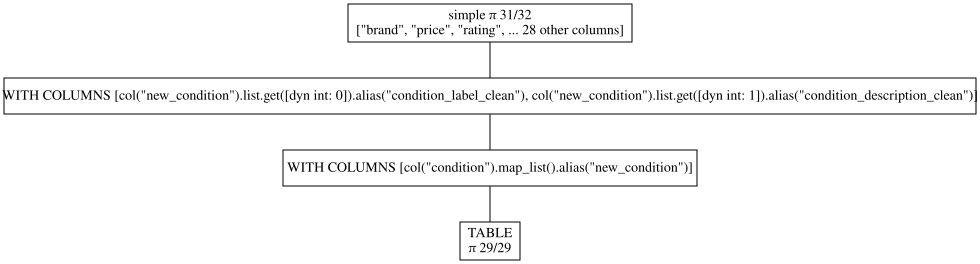

In [199]:
# Transforming the dataframe, creating the `condition_label` and `condition_description` variables
df_lazy_conditions = df.lazy().with_columns(
    pl.col('condition')
    # Applying the `map_condition` function, which maps a string to a predefined label and its corresponding description
    .map_elements(
        function=map_condition,
        skip_nulls=False,
        return_dtype=pl.List(pl.Utf8)
    ).alias('new_condition')  # Creating a temporary column to store results
).with_columns(
    pl.col('new_condition').list.get(0).alias('condition_label_clean'),  # Extract label
    pl.col('new_condition').list.get(1).alias('condition_description_clean')  # Extract description
).drop('new_condition')  # Dropping the temporary column

# Visualize the query plan for the transformation
LazyFrame.show_graph(df_lazy_conditions)

Here we take a look at the values from our `condition` column, and their correspondent **condition labels** and **condition descriptions**.

In [200]:
# Selecting all unique values for condition, and their soon-to-be assigned condition labels and condition descriptions
df_lazy_conditions.unique(
    subset='condition',
    maintain_order=True,
).sort(
    by='condition',
    descending=False,
).select(
    'condition', 'condition_label_clean', 'condition_description_clean'
).collect().to_pandas()

,condition,condition_label_clean,condition_description_clean
0,None,No label,No description
1,Certified - Refurbished: The item is in pristi...,Certified - Refurbished,"The item is in pristine, like-new condition.\n..."
2,Certified - RefurbishedThe item is in pristine...,Certified - Refurbished,"The item is in pristine, like-new condition.\n..."
3,Excellent - Refurbished: The item is in like-n...,Excellent - Refurbished,"The item is in like-new condition, backed by a..."
4,Excellent - RefurbishedThe item is in like-new...,Excellent - Refurbished,"The item is in like-new condition, backed by a..."
5,For parts or not working: An item that does no...,For parts or not working,An item that does not function as intended and...
6,For parts or not workingAn item that does not ...,For parts or not working,An item that does not function as intended and...
7,Good - Refurbished: The item shows moderate we...,Good - Refurbished,The item shows moderate wear and is backed by ...
8,Good - RefurbishedThe item shows moderate wear...,Good - Refurbished,The item shows moderate wear and is backed by ...
9,"New: A brand-new, unused, unopened, undamaged ...",New,"A brand-new, unused, unopened, undamaged item ..."


### **Reformatting `condition`:**

After splitting our `condition` column into `condition_label` and `condition_description`, we will further clean the `condition_label` column by doing the following string operations:
- **Lowercasing:** Modifying all strings to their lowercase equivalent.
- **Standardizing format:** Replacing occurrences hyphens and whitespaces with an underscore (`_`), making the labels more consistent and clean.


In [201]:
# Reformatting `condition_label_clean` and `condition_description_clean`: replacing blank spaces for underscores and lowercasing
df = df_lazy_conditions.with_columns(
    pl.col('condition_label_clean')
    .str.to_lowercase()  # Converting the text to lowercase
    .str.replace_all(' - ', '_')  # Replacing hyphen and spaces between words with underscores
    .str.replace_all(' ', '_')  # Replacing spaces with underscores
    .alias('condition_label_clean')
).collect()  # Materializing the LazyFrame into a DataFrame

# Selecting all unique values for condition, and their respective reformatted condition labels (condition description is not modified, so it is omitted from this lookup)
df.unique(
    subset='condition',
    maintain_order=True,
).sort(
    by='condition',
    descending=False,
).select(
    ['condition', 'condition_label_clean']
)


condition,condition_label_clean
str,str
null,"""no_label"""
"""Certified - Refurbished: The i…","""certified_refurbished"""
"""Certified - RefurbishedThe ite…","""certified_refurbished"""
"""Excellent - Refurbished: The i…","""excellent_refurbished"""
"""Excellent - RefurbishedThe ite…","""excellent_refurbished"""
…,…
"""Seller refurbishedThe item has…","""seller_refurbished"""
"""Used: An item that has been us…","""used"""
"""UsedAn item that has been used…","""used"""


Finally, we take a look at the new `condition_label` variable and its value counts:

In [202]:
# Taking a look at the values counts for the `condition_label_clean` column
value_counts_with_proportion(dataframe=df, col='condition_label_clean')

condition_label_clean,count,proportion
str,u32,f64
"""used""",2794,0.42
"""new""",1931,0.29
"""no_label""",616,0.09
"""seller_refurbished""",578,0.09
"""for_parts_or_not_working""",173,0.03
"""very_good_refurbished""",151,0.02
"""good_refurbished""",132,0.02
"""excellent_refurbished""",106,0.02
"""open_box""",102,0.02


Observations:
- **New label frequencies**: After cleansing, the most common conditions are `used` (42%) and `new` (29%), which account for the majority of the dataset (71%).
- **Lower cardinality**: We have a considerably minor number of unique values within our `condition_label` variable (**just 10 unique values**), than we did with `condition`, due to the proper cleansing of the data.

## Cleaning `processor`
- **Formatting**: Similarly, as done with other variables, we'll reformat the values, so that `Intel Celeron` is transformed into `intel_celeron`.
- **Unknown values**: There's an abundance of brands with very low frequencies, or unknown values (like `?` or `Does not apply` or `no` or `none`).


In [203]:
# Taking a look at the values counts for the `processor` column
value_counts_with_proportion(dataframe=df, col='processor')

processor,count,proportion
str,u32,f64
null,2783,0.42
"""Does not apply""",531,0.08
"""Intel Core i5 4th generation""",318,0.05
"""Intel Celeron""",183,0.03
"""Intel Core i5 6th generation""",183,0.03
…,…,…
"""Cable""",1,0.0
"""AMD Ryzen 7 5800HS""",1,0.0
"""Intel Core I7 8650u""",1,0.0


Observations:
- **Missing data**: 42% of the entries are marked as `null` and 8% as `Does not apply`, together representing 50% of the dataset.
- **Low variety**: All processors in the top 10 are of `Intel` brand, with diversity in performance levels but very little in manufacturer.
- **High cardinality**: `processor` contains 462 unique values, as some of its information contains details such as brand (`intel`/`amd`), model (`celeron`), generation (`8th gen`), etc.
- **Feature engineering potential**: Some processors indicate both the model and the generation (`Intel core i5 8th gen`), which can be extracted for further analysis.

### **Reformatting `processor`:**

In this step of our analysis, we're focusing on cleaning up and standardizing the `brand` data to ensure consistency and accuracy. Brands can be listed in many different ways, which can lead to confusion or misinterpretation during analysis. So, we're transforming the brand names into a uniform format that makes it easier to work with.

- **Consistent Formatting:** We ensure all processor names are in lowercase, and we remove any unnecessary spaces or punctuation that could create inconsistencies. (transforming `Intel core - 7th gen.` into `intel_core_7th_gen`).
- **Replacing Uncertain Values:** We also handle special cases where the data might have uncertain or irrelevant values (e.g., `?` or `no`), replacing them with more meaningful values such as `unknown` or `not_applicable`.

In [204]:
 # Define a mapping to handle various non-standard or missing values in the 'processor' column.
processor_replace_map = {
    '?': 'unknown',
    'none': 'unknown',
    'no': 'unknown',
    '^?': 'unknown',
    'does not apply': 'not_applicable'
}

# Apply the replacement logic to the 'processor' column to clean and standardize the values.
df = df.with_columns(
    pl.col('processor')
    .str.to_lowercase()  # Convert text to lowercase for consistency.
    .str.strip_chars()  # Remove any leading or trailing whitespace.
    .str.replace_all(r'\s+|-', '_')  # Replace spaces / hyphens with underscores for consistent naming.
    .str.replace(',', '')  # Removing comas
    .str.strip_chars_end('.')  # Remove any trailing dots.
    .replace(processor_replace_map)  # Apply the replacement map to clean non-standard values.
    .alias('processor_clean')
)

df.select(
    'processor', 'processor_clean'
).head(n=10)

processor,processor_clean
str,str
"""Quad Core""","""quad_core"""
"""Intel Core i7 8th Gen.""","""intel_core_i7_8th_gen"""
"""Intel Core i5-6300U""","""intel_core_i5_6300u"""
"""Intel Celeron N""","""intel_celeron_n"""
"""Intel Core i5 6th Gen.""","""intel_core_i5_6th_gen"""
"""Intel Celeron""","""intel_celeron"""
"""Intel Celeron""","""intel_celeron"""
"""Intel Celeron Dual-Core""","""intel_celeron_dual_core"""
"""i7 7th""","""i7_7th"""


In [205]:
# Taking a look at the poorly formatted `processor` values, with their correspondent values in `processor_clean`
df.select(
    'processor', 'processor_clean',
).filter(
    pl.col('processor').str.to_lowercase().is_in(processor_replace_map)
).unique(
    subset='processor',
    maintain_order=True,
).sort(
    by='processor',
    descending=False,
)

processor,processor_clean
str,str
"""?""","""unknown"""
"""DOES NOT APPLY""","""does_not_apply"""
"""Does Not Apply""","""does_not_apply"""
"""Does not apply""","""does_not_apply"""
"""NONE""","""unknown"""
"""No""","""unknown"""
"""^?""","""unknown"""
"""none""","""unknown"""


Finally, we inspect visually our newly created `processor_clean` variable:

In [206]:
# Taking a look the new `processor_clean` column and its value counts
value_counts_with_proportion(dataframe=df, col='processor_clean')

processor_clean,count,proportion
str,u32,f64
null,2783,0.42
"""does_not_apply""",538,0.08
"""intel_core_i5_4th_generation""",318,0.05
"""intel_celeron""",183,0.03
"""intel_core_i5_6th_generation""",183,0.03
…,…,…
"""intel_core_i5_10400h""",1,0.0
"""cable""",1,0.0
"""amd_ryzen_7_5800hs""",1,0.0


## Cleaning `screen_size`

In [207]:
# Screen size value counts and their proportion
value_counts_with_proportion(dataframe=df, col='screen_size', to_pandas=True)

,screen_size,count,proportion
0,None,2730,0.41
1,14 in,703,0.11
2,"14""",603,0.09
3,Does not apply,528,0.08
4,15.6 in,485,0.07
...,...,...,...
154,"13.3"" touchscreen",1,0.00
155,14in,1,0.00
156,2 Meter,1,0.00
157,12 Zoll,1,0.00


### Extracting inches from `screen_size`

In order to have an accurate processing of `screen_size`, we'll extract the inches from the `screen_size` column and assign them to a numerical variable named `screen_size_inches`.

In this way, we can perform further analysis, visualization and numerical computations on the screen size, ensuring that we no longer have to deal with mixed formats.

In [208]:
# Define the regex pattern to extract numeric values (floating point or integer) from screen_size column
screen_size_pattern = r'(\d+(\.\d+)?)'

df = df.with_columns(
    # Clean the screen_size column by extracting the numeric part (screen size in inches)
    pl.col('screen_size')
    .str.extract(screen_size_pattern)  # Extract the numeric part
    .cast(pl.Float32)  # Convert the extracted value to Float64
    .alias('screen_size_inches_clean')
)

df['screen_size_inches_clean'].head(n=10)

screen_size_inches_clean
f32
14.0
14.0
14.0
11.6
12.5
11.6
11.6
11.6
14.0


We can now take a look at the summary statistics for the new `screen_size_inches` variable

In [209]:
# Looking at the summary statistics for the `screen_size_inches` variable
df['screen_size_inches_clean'].describe()

statistic,value
str,f64
"""count""",3331.0
"""null_count""",3289.0
"""mean""",14.397553
"""std""",24.215275
"""min""",2.0
"""25%""",13.0
"""50%""",14.0
"""75%""",15.0
"""max""",1000.0


Observations:
- **Wide Distribution**: The `screen_size_inches_clean` column has a mean value of 14.40 inches, with a standard deviation of 24.22 inches, indicating a relatively wide spread in values. 25% of the data is below 13.0 inches, and 75% is below 15.0 inches.
- **Missing Data**: The column contains a significant amount of missing values (`null_count = 3289`). This highlights the need for potential imputation or cleaning strategies to handle missing data effectively.
- **Extreme Outliers**: The minimum value is 2.0 inches, while the maximum reaches up to 1000.0 inches, suggesting some extreme outliers, which could distort any analysis or model using this data. These outliers should be further investigated and possibly removed or transformed, when doing *statistical analysis*.

### Correcting outliers

We're interested in correcting the outliers in the `screen_size_inches` column, as the maximum value is that of a `1000` inches, which makes very little sense. We'll start by visualizing the top values from that column, to see whether we have several outliers or this is just the product of an error in the data extraction process:

In [210]:
df['screen_size_inches_clean'].filter(
    predicate=df['screen_size_inches_clean'].is_not_null()
).sort(
    descending=True,
)

screen_size_inches_clean
f32
1000.0
1000.0
18.4
18.4
18.4
…
4.5
4.5
2.0


We immediately realize we have just two values of `1000` inches, which are heavily skewing the data. The rest of the distribution lies between the range of `2-18` inches, which is sensible.
In order to address this, we need to find where these values are originally located. Which is, the `screen_size` column:

In [211]:
df.select('screen_size').filter(pl.col('screen_size').str.contains('1000'))

screen_size
str
"""Jumbo Heuer 1000"""
"""Jumbo Heuer 1000"""


We come to the immediate realization that `Jumbo Heuer 1000`, the original `screen_size` value, is clearly not a valid screen size.

 It doesn't contain any numeric value that would correspond to a typical screen size in inches (e.g., "15.6", "12.5", etc.). Instead, the word "1000" is part of a non-numeric string, likely from a misformatted entry during the web scraping process, or the scraping of a wrong tag. As a result, extracting 1000 as the screen size would lead to misleading or incorrect analysis of the data, as screen sizes in inches don't reach values like 1000 inches.

Hence, we replace these unreasonable values with `None` to ensure that the data used for analysis remains consistent and meaningful.

In [212]:
# Replace rows where screen_size_inches_clean is equal to a thousand (which is incorrect data)
df = df.with_columns(
    pl.when(pl.col('screen_size_inches_clean').is_in([1000]))  # Handle extreme values
    .then(None)  # Replace with None (we might also consider using a default value, like the mean or median)
    .otherwise(pl.col('screen_size_inches_clean'))
    .alias('screen_size_inches_clean')
)

# Sorting the screen size in inches in descending order
df['screen_size_inches_clean'].filter(
    predicate=df['screen_size_inches_clean'].is_not_null()
).sort(
    descending=True,
)

screen_size_inches_clean
f32
18.4
18.4
18.4
18.0
18.0
…
4.5
4.5
2.0


Now, we see that the maximum value for the *screen size in inches* variable make a lot more sense. We proceed to visualize its summary statistics once again:

In [213]:
# Looking back at the summary statistics for the `screen_size_inches` variable
df['screen_size_inches_clean'].describe()

statistic,value
str,f64
"""count""",3329.0
"""null_count""",3291.0
"""mean""",13.805422
"""std""",1.612389
"""min""",2.0
"""25%""",13.0
"""50%""",14.0
"""75%""",15.0
"""max""",18.4


Observations:
- **Narrower distribution**: The new statistics show a mean of `13.81` inches with a standard deviation of `1.61` inches. This is an **HIGH REDUCTION** in variability, particularly compared to the previous standard deviation of `24.22` inches. This suggests that removing extreme outliers has led to a more consistent and predictable distribution of screen sizes.

## Cleaning `manufacturer_color` & `color`
Manufacturer color consists of the color specified by the laptop manufacturer. By analyzing the value counts in the `manufacturer_color` column, we can visualize that:
- Manufacturer color is almost composed entirely of `NULL` values, with 97% of its values being null.
- Some entries represent multiple colors in a single field (e.g: `Black & Silver`).
- Most entries have very little frequency, appearing a single time in the entire column. These rare values might be considered noise (and grouped into a rare label category, such as `rare` or `other`) or might to be grouped into broader categories by using the color label (such as grouping `Mica Silver` and `Ice Blue` into a broader `Blue` category).

In [214]:
# Color value counts and their proportion
value_counts_with_proportion(dataframe=df, col='manufacturer_color')

manufacturer_color,count,proportion
str,u32,f64
null,6435,0.97
"""Black""",46,0.01
"""Silver""",37,0.01
"""Gray""",12,0.0
"""Natural Silver""",7,0.0
…,…,…
"""Space Gray""",1,0.0
"""Platinum Gray""",1,0.0
"""Gray / Black""",1,0.0


Observations:
- **Almost all data is NULL**: The `manufacturer_color` column contains a large amount of missing data, with 6435 instances marked as `null`, representing 97% of the dataset. This makes the variable have very little influence for further analysis or modeling techniques.
- **Diverse color variants**: The column contains various color names with different variations and formats, such as `Black & Silver` and `Matte Black`, as well as entries like `Iron Grey, Ice Blue` and `Scarlet red cover and base, natural silver keyboard frame` which suggest complex multi-color or detailed descriptions. These need to be **STANDARDIZED FOR CONSISTENCY**.
- **Low Frequency Entries**: A significant number of color values appear only once or twice. These rare values might be considered noise or need to be grouped into broader categories to improve the utility of this feature for analysis or modeling.


Similarly, `color` consists of the actual color of the laptop as listed by the seller. By analyzing the value counts in the `color` column, we can visualize that:
- Color is currently a variable with a high number of nulls, which compose approx. 68% of the column.
- Color contains data in spanish, as evidenced by some of its values: `borgoña` (burgundy), `blanco` (white) or `negro` (black).
- Some entries represent multiple colors in a single field (e.g: `Black/ Blue / Sandtone / Platinum`).

In [215]:
# Color value counts and their proportion
value_counts_with_proportion(dataframe=df, col='color')

color,count,proportion
str,u32,f64
null,4471,0.68
"""Black""",982,0.15
"""Silver""",370,0.06
"""Negro""",264,0.04
"""Gray""",254,0.04
…,…,…
"""Space Gray""",1,0.0
"""Silver and Black""",1,0.0
"""Black / Gray""",1,0.0


Observations:
- **Missing Data**: A significant portion of the data is missing, with 68% of instances marked as `null`. This indicates that a large part of the `color` information is unavailable, which may require additional cleaning, maybe imputation strategies, to handle effectively.
- **Different Languages**: The `color` column includes color names in spanish, such as `Negro` (Spanish for black) and `Gris` (Spanish for gray), as well as English terms like `Carbon Black` and `Silver`. This inconsistency in language could lead to confusion in analysis or models, and standardizing the language or grouping similar colors may be beneficial.
- **Multiple Colors**: Some entries, like `Black/ Blue / Sandtone / Platinum` or `Multicolor`, represent multiple colors in a single field. These values may need to be split into individual colors or categorized into a broader "multicolor" group to maintain consistency and facilitate analysis.

### **Reformatting `manufacturer_color`:**
In this step of our analysis, we're focusing on cleaning up and standardizing the `manufacturer_color` data to ensure consistency and accuracy.
- **Reducing cardinality:** The color data may contain variations or inconsistencies in how colors are labeled (e.g., `multi-color` vs. `multicolor`). We address this by grouping similar colors under consistent labels, reducing the number of unique color categories. We also map color variations (e.g, `sky blue`, `light blue`) to a single color (`blue`).
- **Standardizing format:** Check whether the color listed for each item matches a set of predefined valid colors. Ensures that all color data follows a consistent format.

In [216]:
def fetch_valid_colors_list() -> list[str]:
    """
    Retrieves a list of valid color values used for consistency checks.

    This function returns a predefined list of color names in lowercase, representing common colors
    used in product descriptions, inventory management, or other applications requiring color categorization.
    The list ensures that color values are consistent across various data entries and avoids discrepancies
    in color terminology.

    Returns:
        list[str]: A list of valid color values as strings.

    Example:
        >>> valid_colors = fetch_valid_colors_list()
        >>> valid_colors
        ['beige', 'black', 'blue', 'bronze', 'brown', 'burgundy', 'gold', 'gray', 'green', 'grey',
        'orange', 'pink', 'platinum', 'purple', 'red', 'silver', 'teal', 'white', 'yellow']
    """
    return [
        'beige', 'black', 'blue', 'bronze', 'brown', 'burgundy', 'gold', 'gray', 'green', 'grey',
        'orange', 'pink', 'platinum', 'purple', 'red', 'silver', 'teal', 'white', 'yellow'
    ]


def fetch__spanish_to_english_colors_translation() -> dict[str, str]:
    """
    Retrieves the Spanish-to-English translation map for color names.

    This function returns a dictionary where the keys are color names in Spanish and the values
    are their corresponding English color names. The map is useful for translating Spanish color inputs
    into their standard English representations, ensuring consistency and clarity when working with bilingual
    or internationalized data.

    Returns:
        dict[str, str]: A dictionary mapping Spanish color names to their English equivalents.

    Example:
        >>> colors_translation = fetch__spanish_to_english_colors_translation()
        >>> colors_translation['negro']
        'black'
    """
    return {
        'negro': 'black',
        'borgoña': 'burgundy',
        'platino': 'platinum',
        'gris': 'grey',
        'blanco': 'white',
        'plata transparente': 'transparent silver',
    }


def fetch_default_color_replace_map() -> dict[str, str]:
    """
    Retrieves the color replacement map for various shorthand or alternative color representations.

    This function returns a dictionary where keys represent color names in shorthand or variant forms,
    and values represent the standardized color names. The map includes commonly used abbreviations as well
    as Spanish-to-English translations to ensure consistency across different color-related data entries.
    This map is essential for normalizing color inputs and improving data consistency in applications requiring
    standardized color representations.

    Returns:
        dict[str, str]: A dictionary mapping color shorthands or variants to standardized color names.

    Example:
        >>> color_replace_map = fetch_default_color_replace_map()
        >>> color_replace_map['blk']
        'black'
        >>> color_replace_map['multi']
        'multicolor'
    """
    return {
        'multi': 'multicolor',
        'multi-color': 'multicolor',
        'blk': 'black',
        **fetch__spanish_to_english_colors_translation(),
    }


In [217]:
def clean_color(color: str, valid_colors_list: list[str] = None) -> str:
    """
    Cleans and categorizes the input color string based on a predefined list of valid colors.

    This function processes the input color string (`color`) to determine its category based on matching
    valid color values. It performs the following checks:
    - If the input color string matches multiple valid colors, it returns 'multicolor'.
    - If it matches exactly one valid color, it returns that specific color (e.g., 'red').
    - If no valid colors are found, it returns 'other'.

    The function is useful for standardizing and categorizing color values, especially when handling product descriptions,
    inventory data, or user inputs with potentially varied or unstandardized color names.

    Args:
        color (str): The input color string to be cleaned and categorized. It may include color names in different formats or case.
        valid_colors_list (list[str], optional): A list of valid color values to check against. If not provided, the function uses
                                                  the `valid_color_values` list returned by `fetch_valid_colors_list()`.

    Returns:
        str: The cleaned and categorized color. Possible values are:
             - A valid color name from the `valid_colors_list` (e.g., 'red')
             - 'multicolor' if multiple valid colors are found in the input
             - 'other' if no valid color matches.

    Example:
        >>> clean_color('Red and black shoes')
        'multicolor'
        >>> clean_color('Pink', fetch_valid_colors_list())
        'pink'
        >>> clean_color('Sky Blue')
        'other'
    """
    if valid_colors_list is None:
        valid_colors_list = fetch_valid_colors_list()

    color_count = sum(1 for c in valid_colors_list if c in color.lower())

    if color_count > 1:
        return 'multicolor'
    elif color_count == 1:
        return next((c for c in valid_colors_list if c in color.lower()), 'other')
    else:
        return 'other'


In [218]:
# Creates an expression to search for valid colors
valid_color_string_pattern = "|".join(re.escape(color) for color in fetch_valid_colors_list())

# Prepare the color column by converting to lowercase and applying the color replacements
manufacturer_color_reformatted = (
    pl.col('manufacturer_color')
    .str.to_lowercase()
    .replace(fetch_default_color_replace_map())
)

df = df.with_columns(
    pl.coalesce(
        # If color is valid then apply the `clean_color` function, and map its value to a valid color, multicolor or other (rare label, for invalid color categories)
        pl.when(manufacturer_color_reformatted.str.contains(valid_color_string_pattern))
        .then(manufacturer_color_reformatted.map_elements(clean_color, return_dtype=pl.Utf8)),
        # If color value is set to multicolor, then return multicolor
        pl.when(manufacturer_color_reformatted.eq('multicolor'))
        .then(pl.lit('multicolor'))
        # If value is not multicolor nor a single color,then assign it to `other`
        .otherwise(pl.lit('other'))
    )
    .str.replace('grey',
                 'gray')  # Naturally, we need to map grey to gray (or vice versa) as it represents the same color
    .alias('manufacturer_color_clean')
)

df.select(
    'manufacturer_color', 'manufacturer_color_clean'
).unique(
    subset='manufacturer_color',
    maintain_order=True,
).head(10)

manufacturer_color,manufacturer_color_clean
str,str
null,"""other"""
"""Black""","""other"""
"""Mineral Silver""","""other"""
"""Pure Silver""","""other"""
"""Storm Gray""","""other"""
"""Iron Grey""","""other"""
"""Performance Blue""","""other"""
"""black""","""other"""
"""Graphite Gray""","""other"""


We further inspect the original unique values of the `manufacturer_color` column, and its correspondent mapping in `manufacturer_color_clean`:

In [ ]:
# Taking a look at all the transformed color labels
df.select(
    'manufacturer_color', 'manufacturer_color_clean',
).unique(
    subset='manufacturer_color',
    maintain_order=True,
).sort(
    by='manufacturer_color',
).transpose(
    include_header=True,
    header_name='column_name',
)

### **Reformatting `color`:**
We do similarly with `color` as we did with `manufacturer_color` by translating, reducing cardinality and standardizing its format in the following manner:
- **Translating from Spanish to English:** We translate color names from Spanish to English to ensure that all color information is standardized, regardless of the language it was originally provided in.
- **Reducing cardinality:** The color data may contain variations or inconsistencies in how colors are labeled (e.g., `multi-color` vs. `multicolor`). We address this by grouping similar colors under consistent labels, reducing the number of unique color categories. We also map color variations (e.g, `sky blue`, `light blue`) to a single color (`blue`).
- **Standardizing format:** check whether the color listed for each item matches a set of predefined valid colors. Ensures that all color data follows a consistent format.

In [ ]:
# Prepare the color column by converting to lowercase and applying the color replacements
color_reformatted = (
    pl.col('color')
    .str.to_lowercase()
    .replace(fetch_default_color_replace_map())
)

df = df.with_columns(
    pl.coalesce(
        # If color is valid then apply the `clean_color` function, and map its value to a valid color, multicolor or other (rare label, for invalid color categories)
        pl.when(color_reformatted.str.contains(valid_color_string_pattern))
        .then(color_reformatted.map_elements(clean_color, return_dtype=pl.Utf8)),
        # If color value is set to multicolor, then return multicolor
        pl.when(color_reformatted.eq('multicolor'))
        .then(pl.lit('multicolor'))
        # If value is not multicolor nor a single color,then assign it to `other`
        .otherwise(pl.lit('other'))
    )
    .str.replace('grey',
                 'gray')  # Naturally, we need to map grey to gray (or vice versa) as it represents the same color
    .alias('color_clean')
)

df.select(
    'color', 'color_clean'
).head(n=10)

We further inspect the original unique values of the `color` column, and its correspondent mapping in `color_clean`:

In [ ]:
# Taking a look at all the transformed color labels
df.select(
    'color', 'color_clean',
).unique(
    subset='color',
    maintain_order=True,
).sort(
    by='color',
).transpose(
    include_header=True,
    header_name='column_name',
)

We can also visualize its new value counts:

In [ ]:
# Color cleaned value counts and their proportion
value_counts_with_proportion(dataframe=df, col='color_clean')

Observations:
- **Lower cardinality and higher frequencies**: As a consequence of mapping colors into broader color categories and the rare category (`other`) the cardinality has decreased from more than 80 different colors to 20. This has also caused the increase in the proportion of several categories, such as `black` increasing from 15% to 19%.

## Cleaning `ram_size`, `ssd_capacity` & `hard_drive_capacity`

In [ ]:
def find_capacity(split_str: str, unit_match_str: str, unit_name: str) -> Tuple[Optional[float], str]:
    try:
        if unit_match_str in split_str:
            capacity = re.sub('[a-z]', '', split_str[:split_str.find(unit_match_str)])
            return float(capacity), unit_name
        return None, unit_name
    except ValueError:
        return None, unit_name


def clean_capacity_from_str(capacity: str) -> Tuple[Optional[float], str]:
    # If capacity is none or a blank string
    if capacity is None or not capacity.strip():
        return None, 'unknown'

    # String for caseless comparisons
    capacity_casefold = capacity.casefold()
    # Splitting the casefolded string
    split_str = ''.join(capacity_casefold.split())

    # Checks for gigabytes
    if 'gb' in split_str:
        return find_capacity(split_str=split_str, unit_match_str='gb', unit_name='gigabytes')
    # Checks for terabytes
    elif 'tb' in split_str:
        capacity_in_tb = split_str[split_str.find('tb') - 1:split_str.find('tb')]
        return float(capacity_in_tb), 'terabytes'
    # Checks for megabytes
    elif 'mb' in split_str:
        return find_capacity(split_str=split_str, unit_match_str='mb', unit_name='megabytes')
    # Checks for capacity values without a unit (e.g., '128', '389', or '128 SSD')
    else:
        # Remove alphabetic characters (like 'SSD') from the string
        numeric_str = re.sub(r'[a-zA-Z]', '', split_str)

        # Check if the remaining string is a valid number (integer or float)
        is_numeric = re.match(r'^\d+(\.\d+)?$', numeric_str)

        if is_numeric:
            return float(numeric_str), 'unknown'
    # Unspecified capacity nor unit
    return None, 'unknown'


def extract_capacity_value(capacity: str) -> float:
    return clean_capacity_from_str(capacity)[0]


def extract_capacity_unit(capacity: str) -> str:
    return clean_capacity_from_str(capacity)[1]


In [ ]:
df = df.with_columns(
    pl.col('hard_drive_capacity')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_value, return_dtype=pl.Float64)
    .alias('hard_drive_capacity_clean'),
    pl.col('hard_drive_capacity')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_unit, return_dtype=pl.String)
    .alias('hard_drive_capacity_unit_clean')
)

df.select(
    'hard_drive_capacity', 'hard_drive_capacity_clean', 'hard_drive_capacity_unit_clean'
).unique(
    subset='hard_drive_capacity'
)

In [ ]:
df = df.with_columns(
    pl.col('ram_size')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_value, return_dtype=pl.Float64)
    .alias('ram_size_clean'),
    pl.col('ram_size')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_unit, return_dtype=pl.String)
    .alias('ram_size_unit_clean')
)

df.select(
    'ram_size', 'ram_size_clean', 'ram_size_unit_clean'
).unique(
    subset='ram_size'
)

In [ ]:
df = df.with_columns(
    pl.col('ssd_capacity')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_value, return_dtype=pl.Float64)
    .alias('ssd_capacity_clean'),
    pl.col('ssd_capacity')
    .str.to_lowercase()
    .map_elements(function=extract_capacity_unit, return_dtype=pl.String)
    .alias('ssd_capacity_unit_clean')
)

df.select(
    'ssd_capacity', 'ssd_capacity_clean', 'ssd_capacity_unit_clean'
).unique(
    subset='ssd_capacity'
)

## Cleaning `gpu`

In [ ]:
value_counts_with_proportion(dataframe=df, col='gpu')

In [ ]:
def map_gpu_type(gpu_str: str) -> str:
    """
    Maps GPU names to broader categories based on brand.

    - 'intel' if the GPU name contains 'intel'.
    - 'amd' if the GPU name contains 'amd' or 'radeon'.
    - 'nvidia' if the GPU name contains 'nvidia' or 'geforce'.
    - 'mali' if the GPU name contains 'mali'.
    - 'other' for unknown or unclassified GPU names.

    Args:
        gpu_str (str): The GPU name.

    Returns:
        str: Mapped GPU category.

    Examples:
        >>> map_gpu_type("Intel UHD Graphics")
        'intel'
        >>> map_gpu_type("AMD Radeon RX 6800")
        'amd'
        >>> map_gpu_type("NVIDIA GeForce RTX 3080")
        'nvidia'
        >>> map_gpu_type("ARM Mali-G76")
        'mali'
        >>> map_gpu_type("Unknown GPU")
        'other'
    """
    if gpu_str is None or gpu_str == "":
        return "unknown"

    str_casefold = gpu_str.casefold()

    if "intel" in str_casefold:
        return "intel"
    elif "amd" in str_casefold or "radeon" in str_casefold:
        return "amd"
    elif "nvidia" in str_casefold or "geforce" in str_casefold:
        return "nvidia"
    elif "mali" in str_casefold:
        return "mali"
    else:
        return "other"

In [ ]:
df = df.with_columns(
    pl.col("gpu")
    .map_elements(map_gpu_type, skip_nulls=False, return_dtype=pl.Utf8)
    .alias("gpu_type_clean")
)

value_counts_with_proportion(dataframe=df, col='gpu_type_clean')

## Cleaning `processor_speed`

In [ ]:
value_counts_with_proportion(dataframe=df, col='processor_speed')

In [ ]:
# Helper function to extract the processor speed unit (GHz, MHz, or unknown)
def extract_processor_speed_unit(processor_speed: str) -> Optional[str]:
    """
    Extracts the unit (GHz, MHz, or 'unknown') from the processor speed string.

    Args:
        processor_speed (str): The processor speed string to process (e.g., '2.5 GHz', '2500 MHz').

    Returns:
        Optional[str]: The unit of the processor speed (GHz, MHz, or 'unknown').
    """
    # Null check to guard against None values
    if processor_speed is None:
        return 'unknown'

    # String useful for caseless comparisons
    processor_speed = processor_speed.casefold()

    # Check for GHz or MHz
    if 'ghz' in processor_speed:
        return 'GHz'
    elif 'mhz' in processor_speed:
        return 'MHz'
    else:
        return 'unknown'


# Helper function to extract the numeric value of the processor speed
def extract_processor_speed_value(processor_speed: str) -> Optional[float]:
    """
    Extracts the numeric value of the processor speed from the string (e.g., '2.5 GHz' -> 2.5).

    Args:
        processor_speed (str): The processor speed string to process (e.g., '2.5 GHz', '2500 MHz').

    Returns:
        Optional[float]: The numeric value of the processor speed or None if invalid format.
    """
    if processor_speed is None:
        return None

    # Normalize the string by removing spaces and converting to lowercase
    processor_speed = ''.join(processor_speed.split()).lower()

    # Check if 'hz' is in the processor speed and extract the numeric value
    if 'hz' in processor_speed:
        # Remove spaces and check if the 'hz' is present
        processor_speed = ''.join(processor_speed.split())  # Remove spaces

        # Try to extract the numeric value by looking for the part before 'hz'
        hz_index = processor_speed.find('hz')

        # If there are enough characters before 'hz' (e.g., '2.5 GHz')
        if hz_index - 5 < 0:
            # Extract the part before 'hz'
            number_part = processor_speed[:hz_index]
        else:
            # Extract 5 characters before 'hz' (to cover cases like '2500 MHz')
            number_part = processor_speed[hz_index - 5:hz_index]

        # Try to convert the extracted part to a float
        try:
            return float(number_part)
        except ValueError:
            return None
    else:
        return None

In [ ]:
df = df.with_columns(
    # Extract the numeric value of the processor speed using regex
    pl.col('processor_speed')
    .str.extract(r"(\d+\.\d+|\d+)", group_index=1)  # Extract numeric value (e.g., 2.60 or 2)
    .cast(pl.Float64)  # Convert the result to a float
    .alias('processor_speed_clean'),
    # Extract the unit of the processor speed (GHz, MHz, or unknown)
    pl.col('processor_speed')
    .map_elements(function=extract_processor_speed_unit, skip_nulls=False, return_dtype=pl.String)  # Extract unit part
    .alias('processor_speed_unit_clean')
)

In [ ]:
value_counts_with_proportion(dataframe=df, col='processor_speed_clean')

In [ ]:
value_counts_with_proportion(dataframe=df, col='processor_speed_unit_clean')

## Cleaning `type`

The `type` variable represents the specific type of laptop, such as notebook, ultrabook, 2-in-1, gaming laptop, etc. It is a categorical variable that helps categorize laptops based on their physical design, usage, or form factor.

The main issues with this variable are:
- **Inconsistent format**: The values in the `type` column may not follow a consistent format or include variations in the naming convention (e.g., `Notebook` vs `notebook` or `Ultrabook` vs `ultrabook`).
- **Missing Data**: Like many other columns, the `type` column may also contain missing or null values, which need to be handled.
- **Ambiguity and Overlap**: Some types may overlap or be ambiguous (e.g., laptops that could be classified as both a `notebook` and `ultrabook`), leading to potential confusion or misclassification.

Therefore, it is essential to clean this variable by *standardizing* the names, *handling missing values* & *grouping* similar types.

In [ ]:
value_counts_with_proportion(dataframe=df, col='type')

We will clean the variable as aforementioned, by:
- **Standardizing** the names (e.g., converting everything to `lowercase`, trimming, removing whitespaces).
- **Handling missing values** (e.g., by imputing or categorizing them as 'unknown').
- **Grouping similar types** into broader categories to ensure consistency and ease of analysis (e.g: `chromebook` and `notebooks` both get mapped to the general label `laptop`)).


In [ ]:
def map_laptop_type(type_str: str) -> str:
    """
    Maps the input string representing the type of device to a standard category.

    The function processes the input string to determine the device type based on the following categories:
    - 'laptop' if any of the terms related to laptops are found (e.g., 'netbook', 'notebook', 'laptop', 'macbook', etc.).
    - 'pc' if any of the terms related to personal computers are found (e.g., 'pc', 'computer').
    - 'tablet' if the string mentions 'tablet'.
    - 'other' for any other cases or unrecognized device types.

    If the input string is None, empty, or contains no recognizable device type, the function returns 'unknown'.

    Args:
        type_str (str): The device type string to be processed.

    Returns:
        str: A standardized device type category.

    Example Usage:
    --------------
    >>> map_laptop_type("Macbook Pro 16")
    'laptop'

    >>> map_laptop_type("Desktop PC")
    'pc'

    >>> map_laptop_type("Samsung Tablet")
    'tablet'

    >>> map_laptop_type("Unknown Device")
    'other'

    >>> map_laptop_type("")
    'unknown'
    """
    if type_str is None or type_str == "":  # Check for None or blank
        return 'unknown'

    str_casefold = type_str.casefold()

    laptops = ('netbook', 'notebook', 'laptop', 'macbook', 'thinkpad', 'chromebook', 'ultrabook')
    if any(laptop in str_casefold for laptop in laptops):
        return 'laptop'

    computers = ('pc', 'computer')
    if any(pc in str_casefold for pc in computers):
        return 'pc'

    if 'tablet' in str_casefold:
        return 'tablet'

    return 'other'


In [ ]:
df = df.with_columns(
    pl.col('type')
    .map_elements(map_laptop_type, skip_nulls=False, return_dtype=pl.Utf8)  # Map the function to the 'Type' column
    .alias('laptop_type_clean')  # Create the new column
)

In [ ]:
value_counts_with_proportion(dataframe=df, col='laptop_type_clean')

Observations:
- **Missing Data**: 50% of the data was missing, now mapped to `unknown`, making the dataset more consistent.
- **Consolidation**: Similar types like `Notebook`, `Laptop`, and `Pc Portable` were grouped into broader categories like `laptop` and `pc`, reducing noise. Similarly, rare categories were mapped to the `other` label.
- **Dominant Categories**: The majority of the data now falls into `laptop` (44%), with `unknown` (50%) remaining the largest category due to missing values. Both these categories contain more than 90% of the data.


## Cleaning `release_year`

In [ ]:
value_counts_with_proportion(dataframe=df, col='release_year')

In [ ]:
df = df.with_columns(
    pl.col("release_year")
    .str.extract(r"\b(20[0-2][0-9]|200[0-9])\b")  # Extracts valid years (2000-2024)
    .cast(pl.Int64)  # Convert to integer
    .alias("release_year_clean")
)

In [ ]:
value_counts_with_proportion(dataframe=df, col='release_year_clean')

## Cleaning `maximum_resolution`

In [ ]:
value_counts_with_proportion(dataframe=df, col='maximum_resolution')

In [ ]:
# Dictionary mapping resolution types to their corresponding width and height values
def fetch_default_resolution_replace_map() -> dict[str, list[str]]:
    """
    Retrieves the default resolution replacement map.

    This function returns a dictionary mapping common resolution labels (e.g., 'full hd', 'hd', '2k', '4k')
    to their respective width and height values as strings. The returned map is useful for standardizing
    or translating resolution labels into actual numerical resolution dimensions, which can be utilized
    in various contexts such as media display, video processing, or product descriptions.

    Returns:
        dict[str, list[str]]: A dictionary where the keys are resolution labels (e.g., 'full hd') and the values
                              are lists containing the corresponding width and height values as strings.
                              Example:
                              {
                                  'full hd': ['1920', '1080'],
                                  'hd': ['1280', '720'],
                                  '2k': ['2048', '1080'],
                                  '4k': ['3840', '2160']
                              }

    Example:
        >>> resolution_map = fetch_default_resolution_replace_map()
        >>> resolution_map['hd']
        ['1280', '720']
    """
    return {
        'full hd': ['1920', '1080'],
        'hd': ['1280', '720'],
        '2k': ['2048', '1080'],
        '4k': ['3840', '2160']
    }


def try_get_resolution_value(resolution: str, resolution_dict: dict[str, list[str]], index: int) -> Optional[str]:
    """
    Helper function to retrieve the width or height from the resolution dictionary or the 'width x height' format.

    Args:
        resolution (str): The resolution string to process (e.g., '1920x1080', 'full hd').
        resolution_dict (dict): A dictionary mapping resolution names to their respective width and height.
        index (int): The index (0 for width, 1 for height) to retrieve from the dictionary.

    Returns:
        Optional[str]: The width or height of the resolution as a string, or None if no valid resolution can be extracted.
    """
    # Null check to guard against None values
    if resolution is None:
        return None

    # Normalize the resolution string by removing spaces and converting to lowercase
    resolution = ''.join(resolution.split()).lower()

    # Check if the resolution matches one of the predefined names in the dictionary
    if resolution in resolution_dict:
        return resolution_dict[resolution][index]

    # Check if the resolution contains 'k' and is in the dictionary (e.g., '4k')
    elif 'k' in resolution and resolution in resolution_dict:
        return resolution_dict[resolution][index]

    # Check if the resolution is in the format 'width x height'
    elif 'x' in resolution:
        parts = resolution.split('x')
        if len(parts) == 2:
            # Return the corresponding part (width or height) based on the index
            return re.sub("[a-z()]", '', parts[index]).strip()

    return 'unknown'

In [ ]:
def extract_width_from_resolution_str(resolution: str,
                                      resolution_dict: dict[str, list[str]] = None) -> Optional[str]:
    """
    Extract the width of a display from a resolution string.

    Uses the helper function to retrieve the width from the resolution dictionary or from the 'width x height' format.

    Args:
        resolution (str): The resolution string to process (e.g., '1920x1080', 'full hd').
        resolution_dict (dict, optional): A dictionary mapping resolution names to their respective width and height.

    Returns:
        Optional[str]: The width of the resolution as a string, or None if no valid resolution can be extracted.
    """
    if resolution_dict is None:
        resolution_dict = fetch_default_resolution_replace_map()

    # Try getting the width using the helper function
    return try_get_resolution_value(resolution, resolution_dict, index=0)


def extract_height_from_resolution_str(resolution: str,
                                       resolution_dict: dict[str, list[str]] = None) -> Optional[str]:
    """
    Extract the height of a display from a resolution string.

    Uses the helper function to retrieve the height from the resolution dictionary or from the 'width x height' format.

    Args:
        resolution (str): The resolution string to process (e.g., '1920x1080', 'full hd').
        resolution_dict (dict, optional): A dictionary mapping resolution names to their respective width and height.

    Returns:
        Optional[str]: The height of the resolution as a string, or None if no valid resolution can be extracted.
    """
    if resolution_dict is None:
        resolution_dict = fetch_default_resolution_replace_map()

    # Try getting the height using the helper function
    return try_get_resolution_value(resolution, resolution_dict, index=1)

In [ ]:
df = df.with_columns(
    # Transform the 'maximum_resolution' column to extract the display width
    pl.col('maximum_resolution')
    .str.to_lowercase()  # Convert the resolution string to lowercase for uniformity
    .map_elements(function=extract_width_from_resolution_str, skip_nulls=False,
                  return_dtype=pl.String)  # Apply the width extraction function
    .cast(dtype=pl.Int64, strict=False)  # Cast the result to an integer type
    .shrink_dtype()  # Shrink the data type to the smallest possible type to save memory (if applicable)
    .alias('display_width_clean'),
    # Transform the 'maximum_resolution' column to extract the display height
    pl.col('maximum_resolution')
    .str.to_lowercase()  # Convert the resolution string to lowercase for uniformity
    .map_elements(function=extract_height_from_resolution_str, skip_nulls=False,
                  return_dtype=pl.String)  # Apply the height extraction function
    .cast(dtype=pl.Int64, strict=False)  # Cast the result to an integer type
    .shrink_dtype()  # Shrink the data type to the smallest possible type to save memory (if applicable)
    .alias('display_height_clean')
)

In [ ]:
value_counts_with_proportion(dataframe=df, col='display_height_clean')

In [ ]:
value_counts_with_proportion(dataframe=df, col='display_width_clean')

## Cleaning `model`

The `model` column represents the specific model name or number of the laptop. This could include a combination of words, numbers, and special characters that uniquely identify each laptop model. These values typically provide detailed information about the device, such as the brand, series, generation, and specifications. However, it is essential to understand the structure and characteristics of the data before cleaning it.

Hence, we clean and standardize these model names to ensure consistency and meaningful analysis.

In [ ]:
value_counts_with_proportion(dataframe=df, col='model')

In [ ]:
# Cleaning and standardizing the `model` variable
df = df.with_columns(
    pl.col('model')
    .str.to_lowercase()  # Convert the string to lowercase
    .str.replace_all(r'\s+', '_')  # Replace spaces with underscores
    .str.replace_all(r'[^a-z0-9_]', '')  # Remove non-alphanumeric characters (except underscores)
    .alias('model_clean')  # Create a new column with the cleaned model names
)

df.select(
    'model', 'model_clean'
).head(n=10)

## Cleaning `os`

#### What does it represent?
The `os` column represents the operating system installed on the device. This could include common OS types such as `Windows`, `macOS`, `Linux`, `ChromeOS`, and `Android`.

#### What is wrong with it?
- **Inconsistent formatting**: Some values might be uppercase, lowercase, or a mix.
- **Synonyms and variations**: For example, `"Windows 10"`, `"Win 10"`, and `"Windows10"` should all be grouped under `Windows`.
- **Noisy or irrelevant values**: Some entries might not be valid OS names (e.g., `"See Description"`, `"N/A"`, or random text).
- **Null values**: Devices with no recorded `os`

We now proceed to take a further look at the value counts of the `os` variable:

In [ ]:
# Operating system value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='os')

Observations:
- **Missing Data**: A significant portion of the data is missing, with 54% of instances marked as `null`. This indicates that more than half of the `os` information is unavailable, which will require appropriate handling, such as imputing missing values with an `'unknown'` category or further investigation into why the data is missing.
- **Multiple Variations**: The `os` column contains several variations of the same operating system name, such as `Windows 10 Pro`, `Windows 10`, `Windows 10 Pros`, `Windows 11 Pro`, and `Windows 11 Home`. These should be standardized and mapped to a common label, such as `Windows 10` and `Windows 11` or even `Windows`, in order to reduce redundancy and ensure consistency.
- **Inconsistent Labels**: Entries like `Not Included` or `null` indicate missing or unspecified data that should be grouped as `unknown`. These values should be mapped to a uniform label that indicates the absence of OS information.

We now map the `os` variable to common categories: `linux`, `windows`, `chrome`, `android`, `mac` and `other`.

In [ ]:
# Define a function that maps the OS types based on the text
def map_os_type(os: str) -> str:
    """
    Maps a given operating system string to a predefined category.

    The function checks for various operating system names within the input string
    and returns a simplified category. It handles different variations of OS names
    and returns an 'unknown' category for missing or non-recognized values.

    Parameters:
    os (str): The input string representing the operating system. This can include
              different OS names such as 'Windows', 'Linux', 'macOS', etc.

    Returns:
    str: A standardized operating system category. Possible categories include:
         'linux', 'windows', 'chrome', 'android', 'mac', 'other', 'unknown'.

    Example:
    >>> map_os_type("Windows 10 Pro")
    'windows'

    >>> map_os_type("Ubuntu 20.04")
    'linux'

    >>> map_os_type("Android 11")
    'android'

    >>> map_os_type("Not Included")
    'unknown'
    """
    if os is None or isinstance(os, float) or os == "":  # Check for None or NaN (float type)
        return 'unknown'

    str_casefold = os.casefold()

    # Check for various OS types
    if 'linux' in str_casefold or 'kali' in str_casefold or 'ubuntu' in str_casefold:
        return 'linux'
    elif 'window' in str_casefold or 'windows' in str_casefold or 'win' in str_casefold:
        return 'windows'
    elif 'chrome' in str_casefold:
        return 'chrome'
    elif 'android' in str_casefold:
        return 'android'
    elif 'mac' in str_casefold or 'macos' in str_casefold:
        return 'mac'
    else:
        return 'other'

In [ ]:
df = df.with_columns(
    pl.col("os")  # Select the OS column
    .map_elements(map_os_type, skip_nulls=False, return_dtype=pl.Utf8)  # Apply the function using map_elements
    .alias("os_clean")  # Create a new column with the mapped values
)

# Operating system cleaned value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='os_clean')

## Cleaning `features`

In [ ]:
# Operating system cleaned value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='features')

In [ ]:
df = df.with_columns(
    pl.col('features')
    .str.to_lowercase()
    # .str.replace_all(r',,{2,}', ',')  # Replaces multiple commas with a single comma
    .str.replace_all(r'\s+', '')
    #.str.replace_all('', '_')
    .alias('features_clean')
)

df['features_clean'].head(n=10)

In [ ]:
value_counts_with_proportion(dataframe=df, col='features_clean')

## Cleaning `country_region_of_manufacturer`

This variable represents country where the laptop was manufactured. As it is a string variable, it needs to be standardized and reformatted as required.

We'll start by taking a look at its value counts:

In [ ]:
# Country region of manufacturer value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='country_region_of_manufacturer')

Observations:
- **Missing Data**: The `country_region_of_manufacturer` feature has a large proportion of missing values, with 6417 entries marked as `null`, representing 97% of the dataset. This significant amount of missing data should be addressed through imputation or exclusion strategies.
- **Concentration in Few Regions**: The majority of the values are concentrated in a small set of countries, with China being the most common, followed by the United States and Taiwan. This indicates that the data might be heavily skewed towards certain manufacturers. Other countries such as Japan, Ireland, and Australia have very few entries (less than 1% of the data), which suggests that these values are underrepresented and can be grouped into broader categories for analysis or modeling.


### Reformatting `country_region_of_manufacturer`
We now proceed to reformat the `country_region_of_manufacturer` variable, by doing string operations (such as lowercasing, replacing all whitespaces with underscores) and assigning all `null` values to the `unknown` category.

In [ ]:
df = df.with_columns(
    pl.col('country_region_of_manufacturer')
    .str.to_lowercase()  # Convert all text to lowercase
    .str.replace_all(r'\s+', '_')  # Replace all whitespaces with underscores
    .fill_null('unknown')  # Replace null values with 'unknown'
    .alias('country_of_manufacturer_clean')  # Save as a new column
)

df.select(
    'country_region_of_manufacturer', 'country_of_manufacturer_clean'
).unique(
    subset='country_region_of_manufacturer'
)

In [ ]:
# Country of manufacturer cleaned value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='country_of_manufacturer_clean')

## Cleaning `storage_type`

The `storage_type` column represents the type of storage technology used in the device, such as `HDD`, `SSD`, `eMMC`, or others. This variable typically helps identify the technology driving the device's storage and its performance characteristics.

Possible values in the `storage_type` column include:
- **Standard Storage Types**: Entries like `HDD` (Hard Disk Drive), `SSD` (Solid State Drive), `eMMC` (Embedded MultiMedia Card), and `NVMe`, which are the common and widely recognized storage technologies in laptops.
- **Inconsistent Labels**: Variations in naming conventions, such as `SSD` being labeled as `solid state drive`, or `HDD` being labeled as `Hard Disk` or `hard disk drive`, could create redundancy and inconsistency.
- **Multiple Values**: Some entries might combine multiple storage types, such as `SSD/HDD` or `HDD+SSD`, making it harder to categorize them properly.
- **Missing or Placeholder Data**: Missing values or incorrect placeholders like `null` or `unknown` could be present, which would need to be remapped or cleaned.

We are cleaning this variable to standardize the labels, group similar values, and handle missing or incorrectly formatted data. This will allow for more accurate analysis and ensure the column is more usable in subsequent processes.

In [ ]:
# Storage type value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='storage_type')

Observations:
- **Missing Data**: The `storage_type` column contains a significant number of missing values (`null_count = 4232`), representing 64% of the data.
- **Multiple Formats**: The data includes various representations for similar storage types (e.g., "SSD", "SSD (Solid State Drive)", "Solid State Drive"), which could lead to inconsistencies. These variations need to be standardized and grouped for better analysis and modeling.
- **Uncommon and Irrelevant Entries**: There are a few outlier values such as "Touchscreen", "256GBSSD", and "SSD or SSD", which seem irrelevant to the `storage_type` category. These should be reviewed and cleaned accordingly to ensure data quality.

In [ ]:
def map_storage_type(string: str) -> str:
    """
    Maps the input string representing a storage type to a standard category.

    The function processes the input string to determine the storage type based on categories: `hdd_or_ssd`, `ssd`, `hdd`, `emmc`, `other`, `unknown` etc.

    If the input string is None, empty, or contains no recognizable storage type, the function returns `unknown`.

    Args:
        string (str): The storage type string to be processed.

    Returns:
        str: A standardized storage type category.

    Usage:
    --------------
    >>> map_storage_type("Samsung SSD 256GB")
    'ssd'

    >>> map_storage_type("Seagate HDD 1TB")
    'hdd'

    >>> map_storage_type("Intel SSD + HDD")
    'hdd_or_ssd'

    >>> map_storage_type("SanDisk eMMC")
    'emmc'

    >>> map_storage_type("Unknown Storage")
    'other'

    >>> map_storage_type("")
    'unknown'
    """
    if string is None or string == "":
        return 'unknown'  # Handle None or empty strings before processing

    # String suitable for caseless comparisons
    str_casefold = string.casefold()

    if 'ssd' in str_casefold and 'hdd' in str_casefold:
        return 'hdd_or_ssd'
    elif 'ssd' in str_casefold:
        return 'ssd'
    elif 'hdd' in str_casefold:
        return 'hdd'
    elif 'emmc' in str_casefold:
        return 'emmc'
    else:
        return 'other'


In [ ]:
df = df.with_columns(
    pl.col("storage_type")  # Select the storage_type column
    .map_elements(map_storage_type, skip_nulls=False, return_dtype=pl.Utf8)  # Apply the function using map_elements
    .alias("storage_type_clean")  # Create a new column with the mapped values
)

df.select(
    'storage_type', 'storage_type_clean'
).head(n=10)

Now we can analyze the value counts from our new `storage_type_clean` variable, expecting a big reduction in cardinality and a standard formatting for categorical labels.

In [ ]:
# Storage type cleaned value counts and their proportion.
value_counts_with_proportion(dataframe=df, col='storage_type_clean')

Observations:
- **Missing Data**: A significant portion of the data, 61.6%, is marked as `unknown`, which indicates that a large number of storage types are missing or not provided. This missing data may require further investigation or imputation to handle effectively.
- **Dominant Category**: The most frequent category is `ssd` (35.6%), which suggests that SSD is the predominant storage technology in the dataset, reflecting the growing trend of SSD usage in modern devices.
- **Reduced cardinality**: Cardinality was reduced from 45 different unique values to 6.
- **Minor Categories**: The categories `other` (0.01) and `hdd_or_ssd` (0.01) are very small, suggesting that these cases are very uncommon in the dataset.